## 1. Environment Setup

The required Python libraries are imported and the project `src` directory is added to the Python path so that custom preprocessing and segmentation functions can be used.

Required output folders are also created for storing intermediate datasets, figures, and tables.

**Purpose:** Prepare the notebook environment for the cross-category analysis.


In [ ]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import os
for folder in ["../data/interim", "../outputs/figures", "../outputs/tables"]:
    os.makedirs(folder, exist_ok=True)

## 2. Import Project Functions

The notebook imports custom functions for:

* selecting and aggregating category-level data,
* removing artificial leading-zero periods,
* performing ABC-XYZ segmentation, and
* testing stationarity using the ADF test.

These functions form the main preprocessing and candidate-selection pipeline used in the analysis.


In [2]:
from segmentation import trim_leading_zeros, scope_and_aggregate, abc_xyz_segment
from diagnostics import run_adf_tests

import segmentation
print(dir(segmentation))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'abc_xyz_segment', 'np', 'pd', 'scope_and_aggregate', 'trim_leading_zeros']


In [3]:
sales = pd.read_csv("../data/raw/sales_train_evaluation.csv")
calendar = pd.read_csv("../data/raw/calendar.csv")
calendar['date'] = pd.to_datetime(calendar['date'])

print("Sales shape:", sales.shape)
print("Categories:", sales['cat_id'].unique())

Sales shape: (30490, 1947)
Categories: <ArrowStringArray>
['HOBBIES', 'HOUSEHOLD', 'FOODS']
Length: 3, dtype: str


The analysis focuses on three product categories:

FOODS
HOBBIES
HOUSEHOLD

The calendar date column is converted to datetime format to enable time-series analysis.

## Cross-Category Processing

The three categories are processed separately for **California**.
For each category, the data is reshaped, leading zeros are removed, AX/AY candidates are identified using **ABC-XYZ segmentation**, and their stationarity is tested using the **ADF test**.

The results are saved and combined into a **cross-category summary** for further analysis.


In [4]:
categories = ['FOODS', 'HOBBIES', 'HOUSEHOLD']
all_results = {}
category_long_dfs = {}
category_item_stats = {}

for cat in categories:
    print(f"\n=== Processing {cat} ===")

    item_level, day_cols = scope_and_aggregate(sales, 'CA', cat)
    n_items_raw = item_level.shape[0]
    print(f"{n_items_raw} unique items in CA/{cat}")

    long_df = item_level.melt(id_vars='item_id', var_name='d', value_name='sales')
    long_df = long_df.merge(calendar[['d', 'date']], on='d', how='left')

    n_before = long_df.shape[0]
    long_df = trim_leading_zeros(long_df)
    n_after = long_df.shape[0]
    pct_rows_trimmed = (1 - n_after / n_before) * 100
    print(f"Rows trimmed: {n_before} -> {n_after} ({pct_rows_trimmed:.1f}% removed)")

    items_with_zeros = item_level[item_level.iloc[:, 1] == 0].shape[0]
    print(f"Items with zero on day 1: {items_with_zeros} of {n_items_raw}")

    item_stats = abc_xyz_segment(long_df)
    candidates = item_stats[item_stats['segment'].isin(['AX', 'AY'])]['item_id'].tolist()
    print(f"{len(candidates)} AX/AY candidates in {cat}")

    adf_df = run_adf_tests(long_df, candidates)
    pct_stationary = adf_df['is_stationary'].mean() * 100
    print(f"Tested: {len(adf_df)} of {len(candidates)} candidates | {pct_stationary:.1f}% stationary")

    long_df[long_df['item_id'].isin(candidates)].to_csv(
        f"../data/interim/{cat.lower()}_candidates.csv", index=False)
    item_stats.to_csv(f"../data/interim/{cat.lower()}_segmentation.csv", index=False)
    adf_df.to_csv(f"../data/interim/{cat.lower()}_adf_results.csv", index=False)

    category_long_dfs[cat] = long_df
    category_item_stats[cat] = item_stats

    all_results[cat] = {
        'total_items': n_items_raw,
        'items_with_leading_zeros': items_with_zeros,
        'pct_items_with_leading_zeros': round(items_with_zeros / n_items_raw * 100, 1),
        'ax_ay_candidates': len(candidates),
        'items_tested': len(adf_df),
        'pct_stationary': round(pct_stationary, 1)
    }

summary_df = pd.DataFrame(all_results).T
print("\n=== Cross-Category Summary ===")
print(summary_df)
summary_df.to_csv("../data/interim/cross_category_summary.csv")


=== Processing FOODS ===
1437 unique items in CA/FOODS
Rows trimmed: 2789217 -> 2279871 (18.3% removed)
Items with zero on day 1: 775 of 1437
337 AX/AY candidates in FOODS
Tested: 337 of 337 candidates | 85.2% stationary

=== Processing HOBBIES ===
565 unique items in CA/HOBBIES
Rows trimmed: 1096665 -> 897469 (18.2% removed)
Items with zero on day 1: 375 of 565
106 AX/AY candidates in HOBBIES
Tested: 106 of 106 candidates | 87.7% stationary

=== Processing HOUSEHOLD ===
1047 unique items in CA/HOUSEHOLD
Rows trimmed: 2032227 -> 1657048 (18.5% removed)
Items with zero on day 1: 655 of 1047
283 AX/AY candidates in HOUSEHOLD
Tested: 283 of 283 candidates | 83.4% stationary

=== Cross-Category Summary ===
           total_items  items_with_leading_zeros  \
FOODS           1437.0                     775.0   
HOBBIES          565.0                     375.0   
HOUSEHOLD       1047.0                     655.0   

           pct_items_with_leading_zeros  ax_ay_candidates  items_tested  \
FOO

In [5]:
def count_real_leading_zero_items(item_level, day_cols, min_gap=30):
    count = 0
    for _, row in item_level.iterrows():
        vals = row[day_cols].to_numpy()
        nonzero = vals.nonzero()[0]
        if len(nonzero) > 0 and nonzero[0] > min_gap:
            count += 1
    return count


In [7]:
categories = ['FOODS', 'HOBBIES', 'HOUSEHOLD']
all_results = {}
category_long_dfs = {}
category_item_stats = {}

for cat in categories:
    print(f"\n=== Processing {cat} ===")

    item_level, day_cols = scope_and_aggregate(sales, 'CA', cat)
    n_items_raw = item_level.shape[0]
    print(f"{n_items_raw} unique items in CA/{cat}")

    long_df = item_level.melt(id_vars='item_id', var_name='d', value_name='sales')
    long_df = long_df.merge(calendar[['d', 'date']], on='d', how='left')

    n_before = long_df.shape[0]
    long_df = trim_leading_zeros(long_df)
    n_after = long_df.shape[0]
    pct_rows_trimmed = (1 - n_after / n_before) * 100
    print(f"Rows trimmed: {n_before} -> {n_after} ({pct_rows_trimmed:.1f}% removed)")

    items_with_zeros = count_real_leading_zero_items(item_level, day_cols)
    print(f"Items with real leading-zero stretch (>30 days): {items_with_zeros} of {n_items_raw}")

    item_stats = abc_xyz_segment(long_df)
    candidates = item_stats[item_stats['segment'].isin(['AX', 'AY'])]['item_id'].tolist()
    print(f"{len(candidates)} AX/AY candidates in {cat}")

    adf_df = run_adf_tests(long_df, candidates)
    pct_stationary = adf_df['is_stationary'].mean() * 100
    print(f"Tested: {len(adf_df)} of {len(candidates)} candidates | {pct_stationary:.1f}% stationary")

    long_df[long_df['item_id'].isin(candidates)].to_csv(
        f"../data/interim/{cat.lower()}_candidates.csv", index=False)
    item_stats.to_csv(f"../data/interim/{cat.lower()}_segmentation.csv", index=False)
    adf_df.to_csv(f"../data/interim/{cat.lower()}_adf_results.csv", index=False)

    category_long_dfs[cat] = long_df
    category_item_stats[cat] = item_stats

    all_results[cat] = {
        'total_items': n_items_raw,
        'items_with_leading_zeros': items_with_zeros,
        'pct_items_with_leading_zeros': round(items_with_zeros / n_items_raw * 100, 1),
        'ax_ay_candidates': len(candidates),
        'items_tested': len(adf_df),
        'pct_stationary': round(pct_stationary, 1)
    }

summary_df = pd.DataFrame(all_results).T
print("\n=== Cross-Category Summary ===")
print(summary_df)
summary_df.to_csv("../data/interim/cross_category_summary.csv")


=== Processing FOODS ===
1437 unique items in CA/FOODS
Rows trimmed: 2789217 -> 2279871 (18.3% removed)
Items with real leading-zero stretch (>30 days): 714 of 1437
337 AX/AY candidates in FOODS
Tested: 337 of 337 candidates | 85.2% stationary

=== Processing HOBBIES ===
565 unique items in CA/HOBBIES
Rows trimmed: 1096665 -> 897469 (18.2% removed)
Items with real leading-zero stretch (>30 days): 303 of 565
106 AX/AY candidates in HOBBIES
Tested: 106 of 106 candidates | 87.7% stationary

=== Processing HOUSEHOLD ===
1047 unique items in CA/HOUSEHOLD
Rows trimmed: 2032227 -> 1657048 (18.5% removed)
Items with real leading-zero stretch (>30 days): 548 of 1047
283 AX/AY candidates in HOUSEHOLD
Tested: 283 of 283 candidates | 83.4% stationary

=== Cross-Category Summary ===
           total_items  items_with_leading_zeros  \
FOODS           1437.0                     714.0   
HOBBIES          565.0                     303.0   
HOUSEHOLD       1047.0                     548.0   

         

## 9. Updated Cross-Category Processing

The complete category-level pipeline is rerun using the improved leading-zero diagnostic.

The updated diagnostic counts only items whose first non-zero sale occurs after a 30-day gap.

The resulting counts are:

| Category  | Items | >30-Day Leading Zeros | AX/AY Candidates | Stationary |
| --------- | ----: | --------------------: | ---------------: | ---------: |
| FOODS     | 1,437 |                   714 |              337 |      85.2% |
| HOBBIES   |   565 |                   303 |              106 |      87.7% |
| HOUSEHOLD | 1,047 |                   548 |              283 |      83.4% |

Overall, the three categories provide **726 AX/AY candidate items** for subsequent analysis.


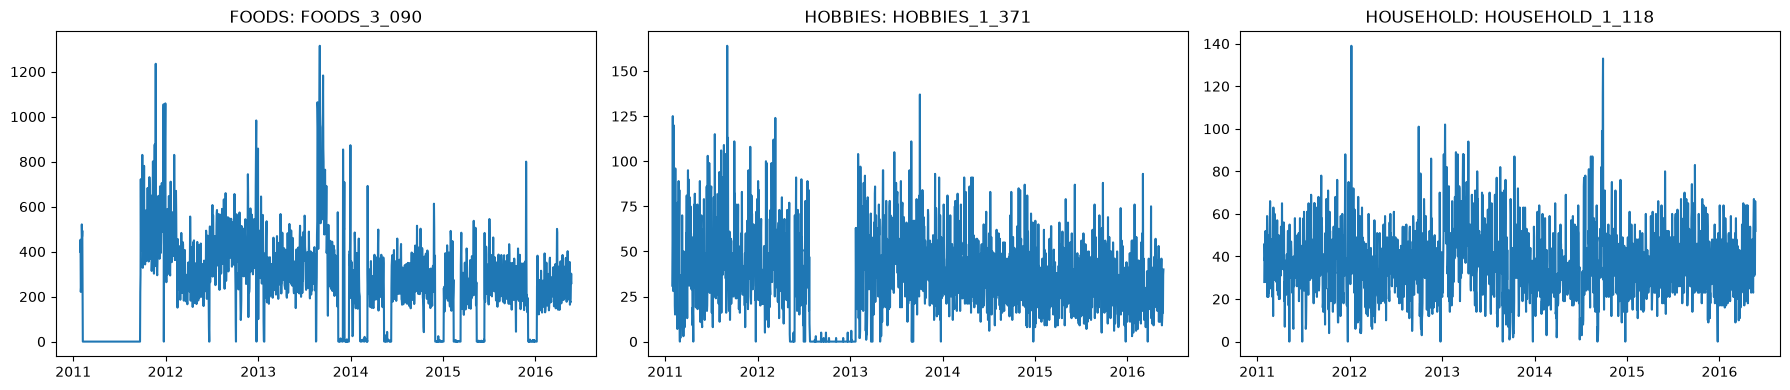

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, cat in zip(axes, categories):
    sample_item = category_item_stats[cat].iloc[0]['item_id']
    series = category_long_dfs[cat][category_long_dfs[cat]['item_id'] == sample_item].sort_values('date')
    ax.plot(series['date'], series['sales'])
    ax.set_title(f"{cat}: {sample_item}")
plt.tight_layout()
plt.savefig("../outputs/figures/cross_category_sample_series.png")
plt.show()

### Conclusion

The three sample series show that M5 demand is highly variable and contains irregular spikes and zero-sales periods. This confirms the need for further structural-break analysis before applying adaptive forecasting methods.

In [9]:
raw = category_long_dfs['FOODS'][category_long_dfs['FOODS']['item_id'] == 'FOODS_3_090'].sort_values('date')
print(raw[['date', 'sales']].head(20))
print("Min date in trimmed data:", raw['date'].min())

              date  sales
1118174 2011-01-29    400
1118175 2011-01-30    453
1118176 2011-01-31    221
1118177 2011-02-01    240
1118178 2011-02-02    232
1118179 2011-02-03    290
1118180 2011-02-04    521
1118181 2011-02-05    467
1118182 2011-02-06    493
1118183 2011-02-07    271
1118184 2011-02-08      0
1118185 2011-02-09      0
1118186 2011-02-10      0
1118187 2011-02-11      0
1118188 2011-02-12      0
1118189 2011-02-13      0
1118190 2011-02-14      0
1118191 2011-02-15      0
1118192 2011-02-16      0
1118193 2011-02-17      0
Min date in trimmed data: 2011-01-29 00:00:00


The cross-category analysis successfully prepared the M5 data for the next stage of the project. After category-wise preprocessing, leading-zero handling, ABC-XYZ segmentation, and ADF testing, **726 AX/AY candidate items** were identified across FOODS, HOBBIES, and HOUSEHOLD.

The sample time-series plots also show noticeable demand fluctuations, spikes, and zero-sales periods, supporting the need for **structural-break detection and adaptive forecasting** in the next phase.